# Assignment 1: Simple Linear Regression

1. Read in the "Computers.csv" file & perform any desired EDA.
2. Fit a regression model with target = "price".  Fit your model on the feature with the strongest correlation to price
3. Interpret the model equation
4. Visualize the residuals of your model
5. Make predictions for common values of your feature

In [8]:
import pandas as pd

computers = pd.read_csv("../Data/Computers.csv")

computers.head()

,price,speed,hd,ram,screen,cd,multi,premium,ads,trend
0,1499,25,80,4,14,no,no,yes,94,1
1,1795,33,85,2,14,no,no,yes,94,1
2,1595,25,170,4,15,no,no,yes,94,1
3,1849,25,170,8,14,no,no,no,94,1
4,3295,33,340,16,14,no,no,yes,94,1


### EDA

In [9]:
computers.select_dtypes("number").corr()

,price,speed,hd,ram,screen,ads,trend
price,1.000000,0.300976,0.430258,0.622748,0.296041,0.054540,-0.199987
speed,0.300976,1.000000,0.372304,0.234760,0.189074,-0.215232,0.405438
hd,0.430258,0.372304,1.000000,0.777726,0.232802,-0.323222,0.577790
ram,0.622748,0.234760,0.777726,1.000000,0.208954,-0.181670,0.276844
screen,0.296041,0.189074,0.232802,0.208954,1.000000,-0.093919,0.188614
ads,0.054540,-0.215232,-0.323222,-0.181670,-0.093919,1.000000,-0.318553
trend,-0.199987,0.405438,0.577790,0.276844,0.188614,-0.318553,1.000000


### Model Fitting

In [20]:
import statsmodels.api as sm
X = sm.add_constant(computers["ram"])
y=computers["price"]
model = sm.OLS(y,X).fit()
model.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.388
Model:                            OLS   Adj. R-squared:                  0.388
Method:                 Least Squares   F-statistic:                     3964.
Date:                Wed, 12 Aug 2026   Prob (F-statistic):               0.00
Time:                        16:05:48   Log-Likelihood:                -47180.
No. Observations:                6259   AIC:                         9.436e+04
Df Residuals:                    6257   BIC:                         9.438e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1687.2925     10.221    165.073      0.000    1667.255    1707.330
ram           64.2316      1.020     62.959      0.000      62.232      66.232
==============================================================================
Omnibus:                     1327.783   Durbin-Watson:                   1.533
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             3113.140
Skew:                           1.188   Prob(JB):                         0.00
Kurtosis:                       5.508   Cond. No.                         17.9
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### Intepretation:


In [14]:
#the equation for this is 1687+64*x
#R^2 is .38 so it explains 38% of the variance not explained by the mean
#since the p value is 0, this means the model is capturing a lot of vaiance not explained by the mean. the same is true for the ram variable

### Plot Residuals

In [21]:
residuals = pd.DataFrame({
    
    "RAM": computers["ram"],
    "Price": computers["price"],
    "Predicted Price": model.predict(),
    "residual": model.resid
})
residuals.head()

,RAM,Price,Predicted Price,residual
0,4,1499,1944.219043,-445.219043
1,2,1795,1815.755790,-20.755790
2,4,1595,1944.219043,-349.219043
3,8,1849,2201.145550,-352.145550
4,16,3295,2714.998564,580.001436


<Axes: xlabel='Predicted Price', ylabel='residual'>

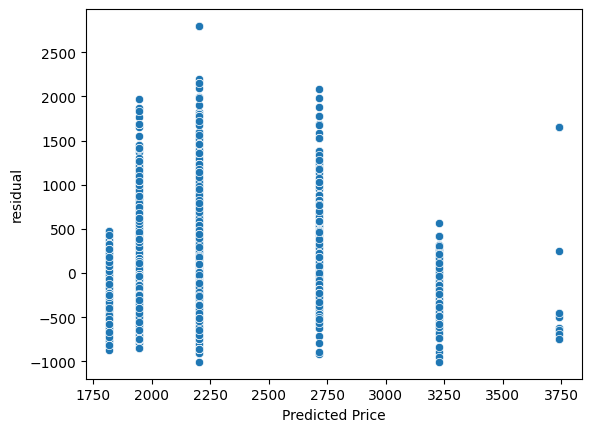

In [24]:
import seaborn as sns
sns.scatterplot(y=residuals["residual"],x=residuals["Predicted Price"])

### Make Predictions with the values below

In [35]:
feature_values = [0, 2, 4, 8, 16, 32, 64]
ram = sm.add_constant(pd.DataFrame({"ram":feature_values}))
model.predict(ram)

0    1687.292537
1    1815.755790
2    1944.219043
3    2201.145550
4    2714.998564
5    3742.704591
6    5798.116644
dtype: float64